# Panel Fixed Effects Regression

This notebook applies **Panel Fixed Effects (FE) regression** to estimate the relationship between democracy / civil liberties indicators and women's legal rights (WBL sub-indices).

## Why FE regression after Granger causality?

Granger causality established *temporal precedence* — democracy changes tend to precede WBL changes — but it does not control for confounders. A country that democratizes may simultaneously receive foreign aid, join international treaties, and improve its economy, all of which could independently drive WBL improvements.

**Panel FE regression** addresses this by:

- **Country (entity) fixed effects** — absorb all time-invariant country characteristics: colonial history, geography, legal tradition, cultural baseline. Only *within-country changes* identify the coefficient.
- **Year fixed effects** — absorb all global shocks common to all countries in a given year: CEDAW ratification waves, global financial crises, international norm shifts.
- **Lagged predictors** — democracy at time *t−k* predicts WBL at time *t*, preserving the temporal ordering established in the Granger analysis.
- **Clustered standard errors** — by entity, to account for serial correlation within countries over time.

The model is:
$$\text{WBL}_{i,t} = \alpha \cdot \text{Democracy}_{i,t-k} + \mu_i + \tau_t + \varepsilon_{i,t}$$

where $\mu_i$ are country FE, $\tau_t$ are year FE, and $k \in \{1, 2, 3, 4\}$ years.

**Remaining limitation:** FE does not solve reverse causality (WBL at $t-1$ also affects democracy at $t$). The coefficient is the net within-country association after controlling for country and year effects, not a fully identified causal estimate.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from linearmodels.panel import PanelOLS

df_raw = pd.read_csv('processed-datasets/merged/democracy_wbl_rdi.csv', low_memory=False)

# ── Polity5 special codes → NaN ───────────────────────────────────────────────
# Values below -10 are special codes (-66 interruption, -77 interregnum, -88 transition)
# and are not valid positions on the -10 to +10 scale.
for col in ['p_polity2', 'p_democ', 'p_autoc']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    df_raw.loc[df_raw[col] < -10, col] = np.nan

# Normalise Polity2 from [-10, +10] to [0, 1] to match the V-Dem scale
df_raw['p_polity2_norm'] = (df_raw['p_polity2'] + 10) / 20

# v_v2lgfemleg is the share of female legislators (0–100%). Divide by 100 to bring
# it onto the same 0–1 scale as all other predictors.
df_raw['v_v2lgfemleg_norm'] = pd.to_numeric(df_raw['v_v2lgfemleg'], errors='coerce') / 100

# ── Religion grouping ─────────────────────────────────────────────────────────
def map_religion(r):
    if pd.isna(r): return 'Others'
    r = str(r).lower()
    if any(x in r for x in ['christian', 'catholic', 'protestant', 'orthodox']): return 'Christian'
    if any(x in r for x in ['muslim', 'islam']): return 'Muslim'
    if 'buddh' in r: return 'Buddhist'
    return 'Others'

df_raw['religion_group'] = df_raw['dominant_religion'].map(map_religion)

# ── Build the panel ───────────────────────────────────────────────────────────
# Use ts_id as the entity identifier (correctly separates e.g. North/South Yemen).
# Drop ts_ids with no orig_ccode (small island states with incomplete records).
# Deduplicate to ensure exactly one row per (ts_id, year).
df_panel = (
    df_raw
    .dropna(subset=['ts_id', 'orig_ccode'])
    .drop_duplicates(subset=['ts_id', 'year'])
    .copy()
)

# Normalise WBL sub-indices from [0, 100] to [0, 1] for coefficient interpretability
wbl_cols = ['wbl_index', 'mobility', 'workplace', 'pay', 'marriage',
            'parenthood', 'entrepreneurship', 'assets', 'pension']
for col in wbl_cols:
    df_panel[col + '_norm'] = df_panel[col] / 100

# Set multi-index required by linearmodels PanelOLS: (entity, time)
df_panel = df_panel.set_index(['ts_id', 'year'])

print(f"Panel dimensions: {df_panel.index.get_level_values(0).nunique()} entities × "
      f"{df_panel.index.get_level_values(1).nunique()} years")
print(f"Total observations: {len(df_panel):,}")

Panel dimensions: 170 entities × 48 years
Total observations: 8,032


## Core Regression Function

For each (democracy predictor, WBL target, lag) combination we fit:

$$\text{WBL\_norm}_{i,t} = \beta \cdot \text{Democracy}_{i,t-k} + \mu_i + \tau_t + \varepsilon_{i,t}$$

Standard errors are clustered at the entity level to account for within-country serial correlation. We require at least 10 entities and 100 observations for a result to be reported.

In [35]:
predictors = {
    'Polity2':                'p_polity2_norm',
    'Electoral Democracy':    'v_v2x_polyarchy',
    'Liberal Democracy':      'v_v2x_libdem',
    'Freedom of Association': 'v_v2x_frassoc_thick',
    'Freedom of Expression':  'v_v2x_freexp_altinf',
    'Rule of Law':            'v_v2x_rule',
    'Civil Society':          'v_v2x_cspart',
    'Female Legislators':     'v_v2lgfemleg_norm',
    'Women Political Empow.': 'v_v2x_gender',
    'Women Civil Society':    'v_v2x_gencs',
}

wbl_targets = {
    'WBL Index':        'wbl_index_norm',
    'Mobility':         'mobility_norm',
    'Workplace':        'workplace_norm',
    'Pay':              'pay_norm',
    'Marriage':         'marriage_norm',
    'Parenthood':       'parenthood_norm',
    'Entrepreneurship': 'entrepreneurship_norm',
    'Assets':           'assets_norm',
    'Pension':          'pension_norm',
}

MIN_OBS      = 100   # minimum observations for a regression to be reported
MIN_ENTITIES = 10    # minimum entities


def run_panel_fe(panel_df, dep_col, indep_col, lag):
    """
    Fit a two-way FE panel regression:
      dep_col(i,t) = β · indep_col(i,t-lag) + entity_FE + time_FE + ε

    Returns a dict with coef, std_err, t_stat, p_value, n_obs, n_entities,
    or None if there is insufficient data or the fit fails.
    """
    lag_col = f'__lag{lag}__'
    sub = panel_df[[dep_col, indep_col]].copy()

    # Create the lagged predictor within each entity (groupby level 0 = ts_id)
    sub[lag_col] = sub.groupby(level=0)[indep_col].shift(lag)
    sub = sub[[dep_col, lag_col]].dropna()

    n_entities = sub.index.get_level_values(0).nunique()
    if len(sub) < MIN_OBS or n_entities < MIN_ENTITIES:
        return None

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            model = PanelOLS(
                dependent=sub[dep_col],
                exog=sub[[lag_col]],
                entity_effects=True,   # absorbs time-invariant country characteristics
                time_effects=True,     # absorbs global year-specific shocks
            )
            # Cluster standard errors by entity to handle within-country serial correlation
            result = model.fit(cov_type='clustered', cluster_entity=True)

        return {
            'coef':       result.params[lag_col],
            'std_err':    result.std_errors[lag_col],
            't_stat':     result.tstats[lag_col],
            'p_value':    result.pvalues[lag_col],
            'n_obs':      int(result.nobs),
            'n_entities': n_entities,
        }
    except Exception:
        return None


print("Functions defined. Ready to run regressions.")

Functions defined. Ready to run regressions.


## Forward Direction: Democracy / Civil Liberties → WBL

We run one regression per (predictor, WBL target) combination at **lag 1** (democracy at *t−1* predicting WBL at *t*) as the baseline specification, then check robustness at lags 2–4.

In [36]:
LAGS = [1, 2, 3, 4]

# Run all (predictor, target, lag) combinations
fwd_rows = []
for pred_name, pred_col in predictors.items():
    for tgt_name, tgt_col in wbl_targets.items():
        for lag in LAGS:
            res = run_panel_fe(df_panel, tgt_col, pred_col, lag)
            if res is not None:
                fwd_rows.append({
                    'Predictor': pred_name,
                    'Target':    tgt_name,
                    'Lag':       lag,
                    **res,
                })

fwd_df = pd.DataFrame(fwd_rows)
fwd_df['sig'] = pd.cut(
    fwd_df['p_value'],
    bins=[-np.inf, 0.01, 0.05, 0.1, np.inf],
    labels=['***', '**', '*', ''],
)

print(f"Regressions run: {len(fwd_df)}")
print(f"Significant at p<0.05: {(fwd_df['p_value'] < 0.05).sum()} "
      f"({100*(fwd_df['p_value'] < 0.05).mean():.1f}%)")

# Show baseline (lag 1) results
lag1 = fwd_df[fwd_df['Lag'] == 1].copy()
print("\nBaseline results (lag 1):")
display(
    lag1[['Predictor','Target','coef','std_err','t_stat','p_value','sig','n_obs','n_entities']]
    .sort_values('p_value')
    .head(20)
    .round(4)
)

Regressions run: 360
Significant at p<0.05: 224 (62.2%)

Baseline results (lag 1):


,Predictor,Target,coef,std_err,t_stat,p_value,sig,n_obs,n_entities
268,Female Legislators,Marriage,0.3803,0.0565,6.7294,0.0000,***,6883,165
256,Female Legislators,Mobility,0.2248,0.0363,6.1866,0.0000,***,6883,165
288,Women Political Empow.,WBL Index,0.2367,0.0418,5.6659,0.0000,***,7569,165
192,Rule of Law,Pay,0.2637,0.0501,5.2678,0.0000,***,7659,165
180,Rule of Law,WBL Index,0.1147,0.0228,5.0255,0.0000,***,7659,165
252,Female Legislators,WBL Index,0.2144,0.0452,4.7417,0.0000,***,6883,165
72,Liberal Democracy,WBL Index,0.1287,0.0278,4.6218,0.0000,***,7605,165
80,Liberal Democracy,Workplace,0.2339,0.0537,4.3548,0.0000,***,7605,165
304,Women Political Empow.,Marriage,0.2566,0.0597,4.2970,0.0000,***,7569,165
36,Electoral Democracy,WBL Index,0.1005,0.0240,4.1865,0.0000,***,7664,165


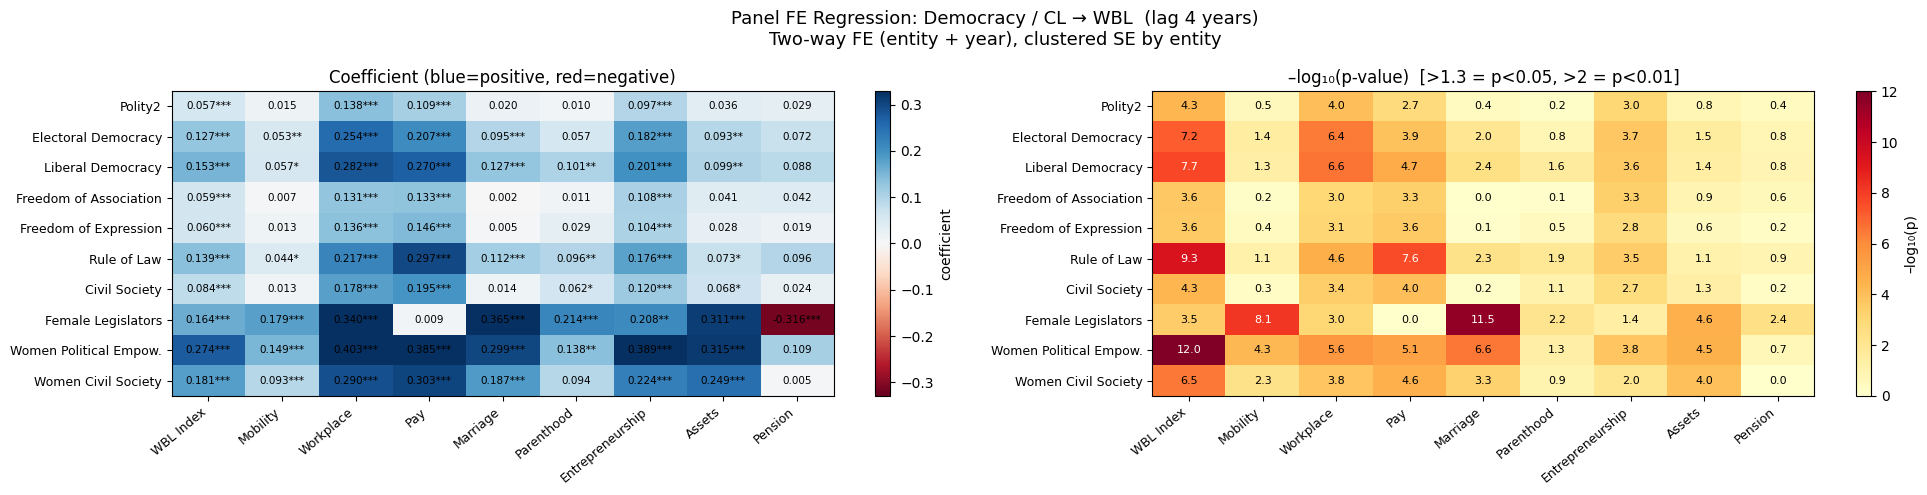

In [37]:
pred_order = list(predictors.keys())
tgt_order  = list(wbl_targets.keys())

def make_fe_heatmaps(df_lag, lag_label):
    coef_mat   = df_lag.pivot(index='Predictor', columns='Target', values='coef').reindex(index=pred_order, columns=tgt_order)
    pval_mat   = df_lag.pivot(index='Predictor', columns='Target', values='p_value').reindex(index=pred_order, columns=tgt_order)
    logp_mat   = -np.log10(pval_mat.clip(lower=1e-50))

    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle(
        f'Panel FE Regression: Democracy / CL → WBL  ({lag_label})\n'
        f'Two-way FE (entity + year), clustered SE by entity',
        fontsize=13
    )

    # Panel A: coefficient value
    # A positive coefficient means: democracy ↑ by 1 unit (0–1 scale) → WBL ↑ by coef units (0–1 scale)
    vmax = np.nanpercentile(np.abs(coef_mat.values), 95)
    im1 = axes[0].imshow(coef_mat.values, aspect='auto', cmap='RdBu', vmin=-vmax, vmax=vmax)
    axes[0].set_xticks(range(len(tgt_order)));  axes[0].set_xticklabels(tgt_order, rotation=40, ha='right', fontsize=9)
    axes[0].set_yticks(range(len(pred_order))); axes[0].set_yticklabels(pred_order, fontsize=9)
    axes[0].set_title('Coefficient (blue=positive, red=negative)')
    for i in range(len(pred_order)):
        for j in range(len(tgt_order)):
            v = coef_mat.values[i, j]
            p = pval_mat.values[i, j]
            if not np.isnan(v):
                star = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
                axes[0].text(j, i, f'{v:.3f}{star}', ha='center', va='center', fontsize=7.5, color='black')
    plt.colorbar(im1, ax=axes[0], label='coefficient')

    # Panel B: –log10(p-value) — significance
    im2 = axes[1].imshow(logp_mat.values, aspect='auto', cmap='YlOrRd', vmin=0)
    axes[1].set_xticks(range(len(tgt_order)));  axes[1].set_xticklabels(tgt_order, rotation=40, ha='right', fontsize=9)
    axes[1].set_yticks(range(len(pred_order))); axes[1].set_yticklabels(pred_order, fontsize=9)
    axes[1].set_title('–log₁₀(p-value)  [>1.3 = p<0.05, >2 = p<0.01]')
    for i in range(len(pred_order)):
        for j in range(len(tgt_order)):
            v = logp_mat.values[i, j]
            if not np.isnan(v):
                axes[1].text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8,
                             color='white' if v > logp_mat.values.max() * 0.6 else 'black')
    plt.colorbar(im2, ax=axes[1], label='–log₁₀(p)')

    plt.tight_layout()
    return fig

lag4 = fwd_df[fwd_df['Lag'] == 4].copy()
fig = make_fe_heatmaps(lag4, 'lag 4 years')
fig.savefig('images/fe_heatmap_lag4_fwd.png', dpi=150, bbox_inches='tight')
plt.show()


## Robustness: Coefficients Across Lags 1–4

If the effect is causal, we expect:
- Positive coefficients at multiple lags (not just one)
- The magnitude may peak at a particular lag reflecting the typical policy response time
- Coefficients should decay or stabilise at longer lags

A coefficient that is significant only at lag 4 but not lag 1 may indicate a slow-acting channel or a spurious correlation.

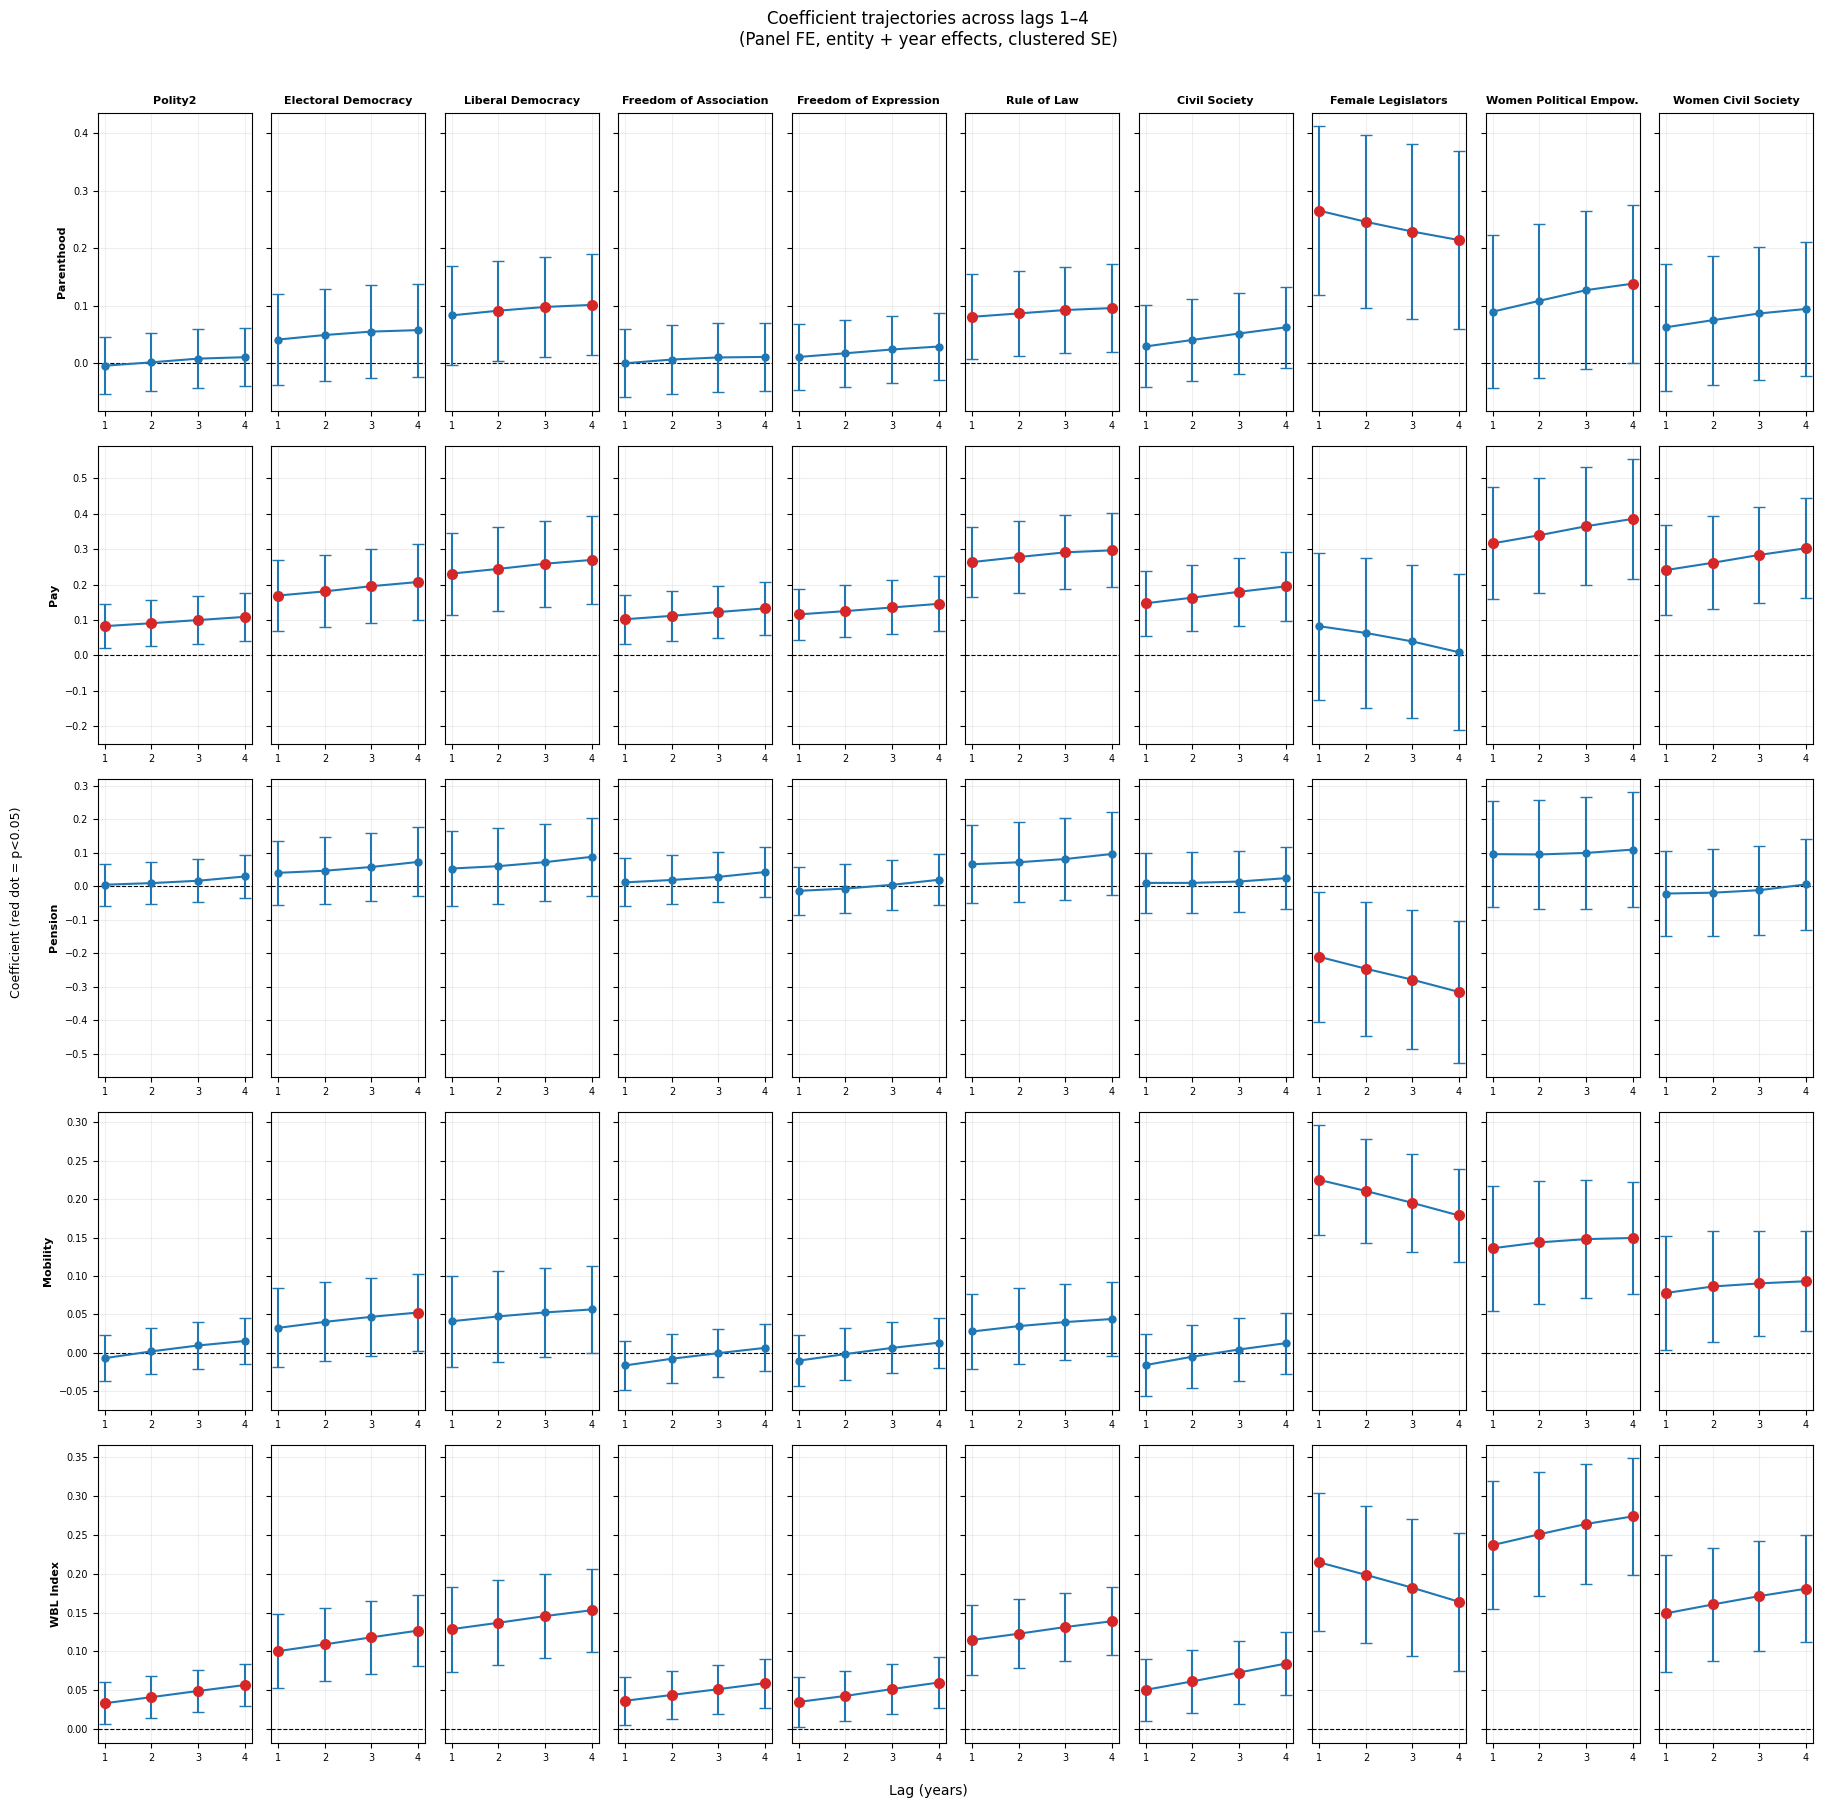

In [38]:
# Plot coefficient trajectories across lags for each predictor → target pair
# Focus on the most informative pairs: all predictors vs Parenthood, Pay, and Pension
focus_targets = ['Parenthood', 'Pay', 'Pension', 'Mobility', 'WBL Index']

fig, axes = plt.subplots(len(focus_targets), len(predictors), figsize=(18, 3.5 * len(focus_targets)), sharey='row')
fig.suptitle('Coefficient trajectories across lags 1–4\n(Panel FE, entity + year effects, clustered SE)', fontsize=12, y=1.01)

for row, tgt_name in enumerate(focus_targets):
    for col, pred_name in enumerate(predictors):
        ax = axes[row, col]
        sub = fwd_df[(fwd_df['Predictor'] == pred_name) & (fwd_df['Target'] == tgt_name)].sort_values('Lag')

        if sub.empty:
            ax.set_visible(False)
            continue

        # Plot coefficient with 95% CI (±1.96 * SE)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.errorbar(
            sub['Lag'], sub['coef'],
            yerr=1.96 * sub['std_err'],
            fmt='o-', color='#1f77b4', linewidth=1.5, markersize=5, capsize=4,
        )
        # Mark significance
        for _, r in sub.iterrows():
            if r['p_value'] < 0.05:
                ax.plot(r['Lag'], r['coef'], 'o', color='#d62728', markersize=7, zorder=5)

        if row == 0:
            ax.set_title(pred_name, fontsize=8, fontweight='bold')
        if col == 0:
            ax.set_ylabel(tgt_name, fontsize=8, fontweight='bold')
        ax.set_xticks(LAGS)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.2)

fig.text(0.5, -0.01, 'Lag (years)', ha='center', fontsize=10)
fig.text(-0.01, 0.5, 'Coefficient (red dot = p<0.05)', va='center', rotation='vertical', fontsize=9)
plt.tight_layout()
plt.savefig('images/fe_lag_trajectories_fwd.png', dpi=150, bbox_inches='tight')
plt.show()

## Reverse Direction: WBL → Democracy / Civil Liberties

Same specification with roles swapped: past WBL sub-index values predicting future democracy / civil liberties levels. Comparing forward vs reverse coefficient magnitudes provides further evidence on the dominant direction.

Reverse regressions run: 360
Significant at p<0.05: 145 (40.3%)


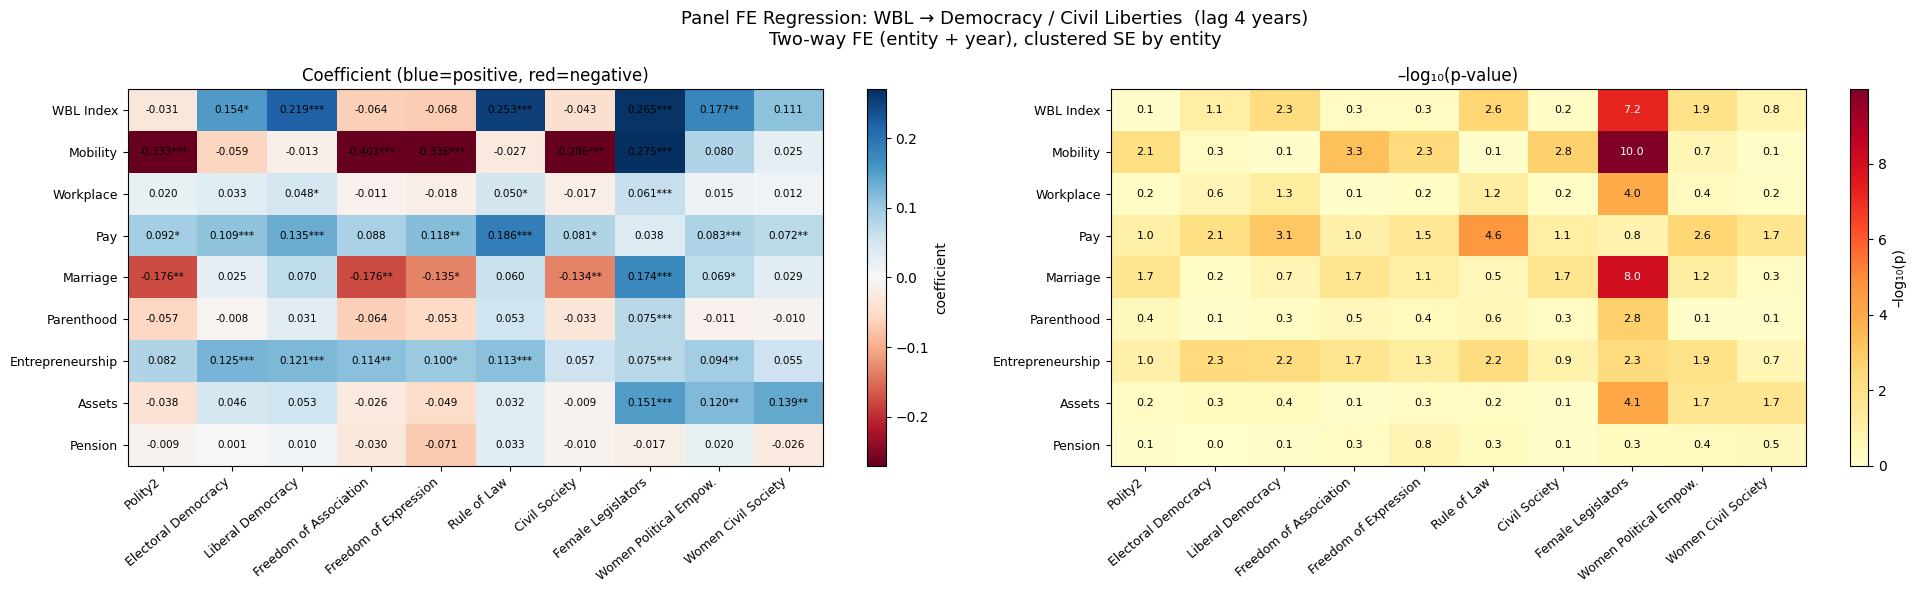

In [39]:
rev_rows = []
for tgt_name, tgt_col in wbl_targets.items():
    for pred_name, pred_col in predictors.items():
        for lag in LAGS:
            # Now WBL (tgt_col) is the predictor, democracy (pred_col) is the dependent
            res = run_panel_fe(df_panel, pred_col, tgt_col, lag)
            if res is not None:
                rev_rows.append({
                    'WBL Predictor':       tgt_name,
                    'Democracy/CL Target': pred_name,
                    'Lag':                 lag,
                    **res,
                })

rev_df = pd.DataFrame(rev_rows)
rev_df['sig'] = pd.cut(
    rev_df['p_value'],
    bins=[-np.inf, 0.01, 0.05, 0.1, np.inf],
    labels=['***', '**', '*', ''],
)

print(f"Reverse regressions run: {len(rev_df)}")
print(f"Significant at p<0.05: {(rev_df['p_value'] < 0.05).sum()} "
      f"({100*(rev_df['p_value'] < 0.05).mean():.1f}%)")

rev_lag4 = rev_df[rev_df['Lag'] == 4].copy()

# Heatmap for reverse direction at lag 4
wbl_order  = list(wbl_targets.keys())
dem_order  = list(predictors.keys())

coef_rev = rev_lag4.pivot(index='WBL Predictor', columns='Democracy/CL Target', values='coef').reindex(index=wbl_order, columns=dem_order)
pval_rev = rev_lag4.pivot(index='WBL Predictor', columns='Democracy/CL Target', values='p_value').reindex(index=wbl_order, columns=dem_order)
logp_rev = -np.log10(pval_rev.clip(lower=1e-50))

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Panel FE Regression: WBL → Democracy / Civil Liberties  (lag 4 years)\nTwo-way FE (entity + year), clustered SE by entity', fontsize=13)

vmax = np.nanpercentile(np.abs(coef_rev.values), 95)
im1 = axes[0].imshow(coef_rev.values, aspect='auto', cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[0].set_xticks(range(len(dem_order)));  axes[0].set_xticklabels(dem_order, rotation=40, ha='right', fontsize=9)
axes[0].set_yticks(range(len(wbl_order))); axes[0].set_yticklabels(wbl_order, fontsize=9)
axes[0].set_title('Coefficient (blue=positive, red=negative)')
for i in range(len(wbl_order)):
    for j in range(len(dem_order)):
        v = coef_rev.values[i, j]
        p = pval_rev.values[i, j]
        if not np.isnan(v):
            star = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
            axes[0].text(j, i, f'{v:.3f}{star}', ha='center', va='center', fontsize=7.5, color='black')
plt.colorbar(im1, ax=axes[0], label='coefficient')

im2 = axes[1].imshow(logp_rev.values, aspect='auto', cmap='YlOrRd', vmin=0)
axes[1].set_xticks(range(len(dem_order)));  axes[1].set_xticklabels(dem_order, rotation=40, ha='right', fontsize=9)
axes[1].set_yticks(range(len(wbl_order))); axes[1].set_yticklabels(wbl_order, fontsize=9)
axes[1].set_title('–log₁₀(p-value)')
for i in range(len(wbl_order)):
    for j in range(len(dem_order)):
        v = logp_rev.values[i, j]
        if not np.isnan(v):
            axes[1].text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8,
                         color='white' if v > logp_rev.values.max() * 0.6 else 'black')
plt.colorbar(im2, ax=axes[1], label='–log₁₀(p)')

plt.tight_layout()
plt.savefig('images/fe_heatmap_lag4_rev.png', dpi=150, bbox_inches='tight')
plt.show()

## Forward vs Reverse: Coefficient Comparison

A direct comparison of the coefficient magnitudes in both directions at lag 4. If the forward coefficients are systematically larger, it confirms the democracy-first ordering found in the Granger analysis.

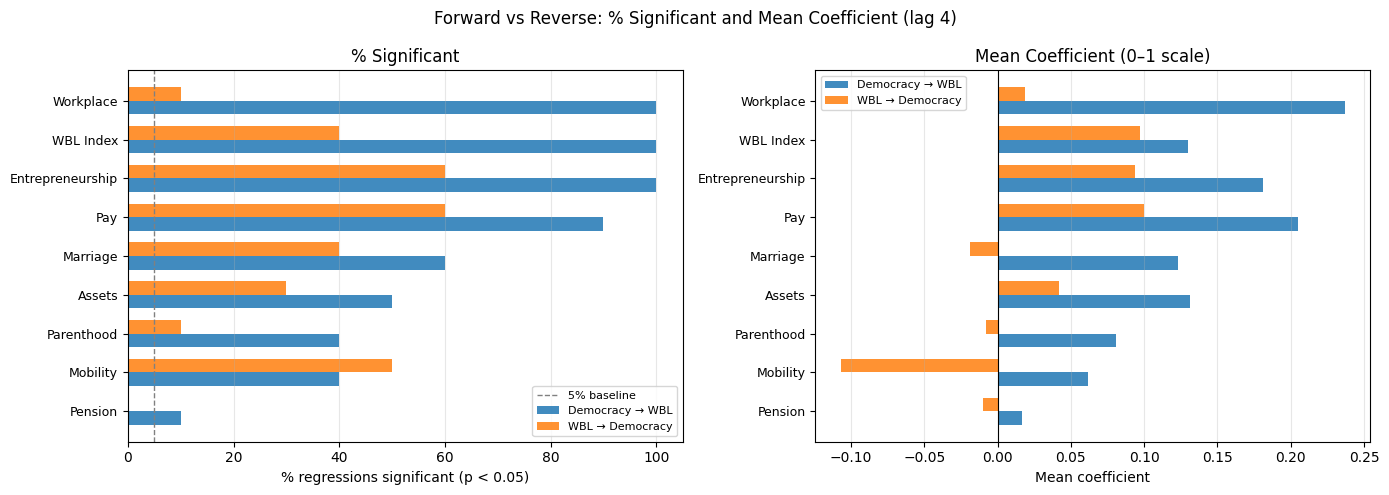

Forward direction (Democracy → WBL, lag 4) summary:


,mean_coef,mean_abs_coef,pct_sig,pct_positive
Target,,,,
Entrepreneurship,0.181,0.181,100.0,100.0
WBL Index,0.130,0.130,100.0,100.0
Workplace,0.237,0.237,100.0,100.0
Pay,0.205,0.205,90.0,100.0
Marriage,0.123,0.123,60.0,100.0
Assets,0.131,0.131,50.0,100.0
Mobility,0.062,0.062,40.0,100.0
Parenthood,0.081,0.081,40.0,100.0
Pension,0.017,0.080,10.0,90.0



Reverse direction (WBL → Democracy/CL, lag 4) summary:


,mean_coef,mean_abs_coef,pct_sig,pct_positive
WBL Predictor,,,,
Entrepreneurship,0.094,0.094,60.0,100.0
Pay,0.100,0.100,60.0,100.0
Mobility,-0.107,0.183,50.0,30.0
Marriage,-0.019,0.105,40.0,60.0
WBL Index,0.097,0.138,40.0,60.0
Assets,0.042,0.066,30.0,60.0
Parenthood,-0.008,0.040,10.0,30.0
Workplace,0.019,0.029,10.0,70.0
Pension,-0.010,0.023,0.0,40.0


In [40]:
# Summary: mean absolute coefficient and % significant, forward vs reverse at lag 4
fwd_summary = (
    fwd_df[fwd_df['Lag'] == 4]
    .groupby('Target')
    .agg(
        mean_coef      = ('coef', 'mean'),
        mean_abs_coef  = ('coef', lambda x: np.abs(x).mean()),
        pct_sig        = ('p_value', lambda x: (x < 0.05).mean() * 100),
        pct_positive   = ('coef', lambda x: (x > 0).mean() * 100),
    ).round(3)
)

rev_summary = (
    rev_df[rev_df['Lag'] == 4]
    .groupby('WBL Predictor')
    .agg(
        mean_coef      = ('coef', 'mean'),
        mean_abs_coef  = ('coef', lambda x: np.abs(x).mean()),
        pct_sig        = ('p_value', lambda x: (x < 0.05).mean() * 100),
        pct_positive   = ('coef', lambda x: (x > 0).mean() * 100),
    ).round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Forward vs Reverse: % Significant and Mean Coefficient (lag 4)', fontsize=12)

order = fwd_summary.sort_values('pct_sig', ascending=True).index.tolist()

x = np.arange(len(order))
w = 0.35
axes[0].barh(x - w/2, fwd_summary.loc[order, 'pct_sig'], w, label='Democracy → WBL', color='#1f77b4', alpha=0.85)
axes[0].barh(x + w/2, rev_summary.loc[order, 'pct_sig'], w, label='WBL → Democracy', color='#ff7f0e', alpha=0.85)
axes[0].set_yticks(x); axes[0].set_yticklabels(order, fontsize=9)
axes[0].axvline(5, color='grey', linestyle='--', linewidth=1, label='5% baseline')
axes[0].set_xlabel('% regressions significant (p < 0.05)')
axes[0].set_title('% Significant')
axes[0].legend(fontsize=8)
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(x - w/2, fwd_summary.loc[order, 'mean_coef'], w, label='Democracy → WBL', color='#1f77b4', alpha=0.85)
axes[1].barh(x + w/2, rev_summary.loc[order, 'mean_coef'], w, label='WBL → Democracy', color='#ff7f0e', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_yticks(x); axes[1].set_yticklabels(order, fontsize=9)
axes[1].set_xlabel('Mean coefficient')
axes[1].set_title('Mean Coefficient (0–1 scale)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('images/fe_fwd_vs_rev.png', dpi=150, bbox_inches='tight')
plt.show()

print("Forward direction (Democracy → WBL, lag 4) summary:")
display(fwd_summary.sort_values('pct_sig', ascending=False))
print("\nReverse direction (WBL → Democracy/CL, lag 4) summary:")
display(rev_summary.sort_values('pct_sig', ascending=False))

## Analysis by Dominant Religion

Repeat the forward FE regression separately for each broad religion group. We report the mean coefficient and % significant across all predictor × WBL target pairs at lag 1.

In [41]:
# Map each ts_id to its religion group
religion_map = (
    df_raw[['ts_id', 'religion_group']]
    .drop_duplicates('ts_id')
    .set_index('ts_id')['religion_group']
    .to_dict()
)

religion_fe_results = {}
for religion in ['Christian', 'Muslim', 'Buddhist', 'Others']:
    ts_ids = [ts for ts, r in religion_map.items() if r == religion]
    # Filter panel df to this religion's entities
    sub_panel = df_panel[df_panel.index.get_level_values(0).isin(ts_ids)]
    print(f"Running {religion:<12} ({len(ts_ids)} ts_ids, {len(sub_panel):,} obs)...")

    rows = []
    for pred_name, pred_col in predictors.items():
        for tgt_name, tgt_col in wbl_targets.items():
            res = run_panel_fe(sub_panel, tgt_col, pred_col, lag=1)
            if res is not None:
                rows.append({'Predictor': pred_name, 'Target': tgt_name, **res})
    if rows:
        religion_fe_results[religion] = pd.DataFrame(rows)

print("Done.")

Running Christian    (110 ts_ids, 4,867 obs)...
Running Muslim       (48 ts_ids, 2,157 obs)...
Running Buddhist     (8 ts_ids, 384 obs)...
Running Others       (13 ts_ids, 624 obs)...
Done.


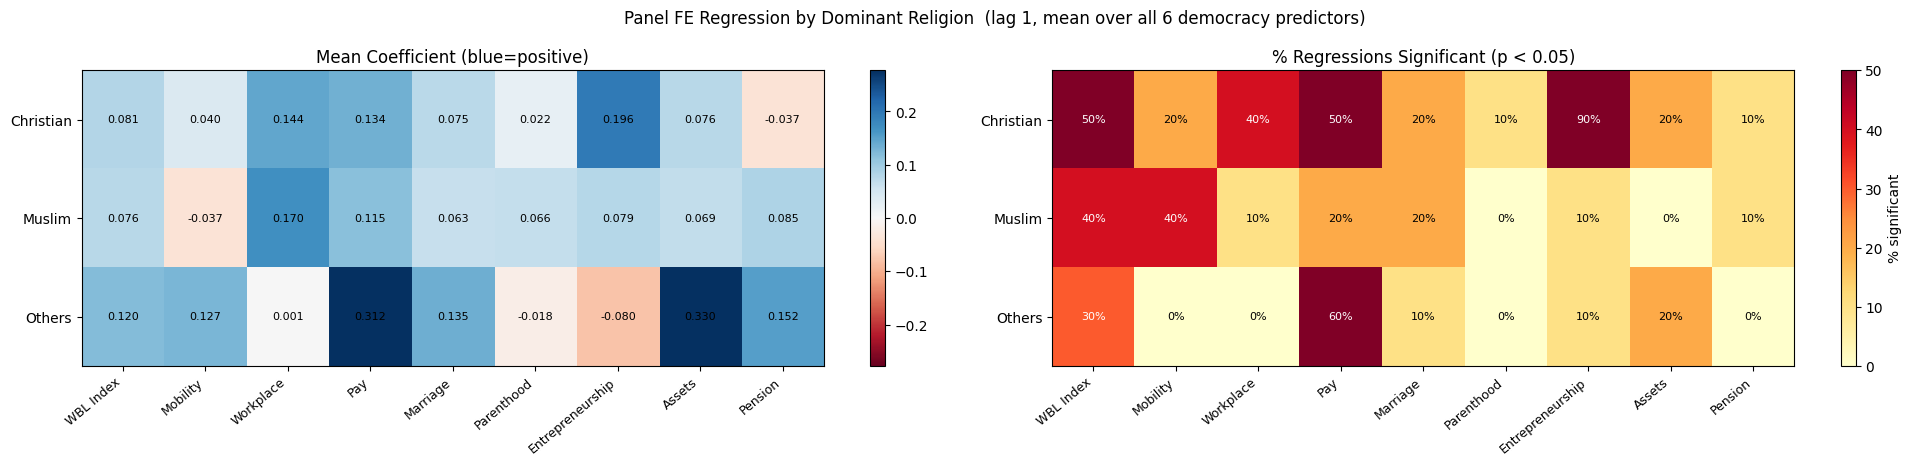

In [42]:
# Build religion × WBL target summary matrices (averaged over all 6 predictors)
religions = ['Christian', 'Muslim', 'Buddhist', 'Others']

coef_by_rel  = {}
pct_by_rel   = {}

for religion in religions:
    if religion not in religion_fe_results:
        continue
    grp = religion_fe_results[religion].groupby('Target')
    coef_by_rel[religion] = grp['coef'].mean().reindex(tgt_order)
    pct_by_rel[religion]  = grp['p_value'].apply(lambda x: (x < 0.05).mean() * 100).reindex(tgt_order)

coef_mat_rel = pd.DataFrame(coef_by_rel).T
pct_mat_rel  = pd.DataFrame(pct_by_rel).T

n_rel = len(coef_mat_rel)
fig, axes = plt.subplots(1, 2, figsize=(20, max(3, n_rel * 0.9 + 2)))
fig.suptitle('Panel FE Regression by Dominant Religion  (lag 1, mean over all 6 democracy predictors)', fontsize=12)

# Coefficient heatmap
vmax = np.nanpercentile(np.abs(coef_mat_rel.values), 95)
im1 = axes[0].imshow(coef_mat_rel.values, aspect='auto', cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[0].set_xticks(range(len(tgt_order)));  axes[0].set_xticklabels(tgt_order, rotation=40, ha='right', fontsize=9)
axes[0].set_yticks(range(n_rel));            axes[0].set_yticklabels(coef_mat_rel.index, fontsize=10)
axes[0].set_title('Mean Coefficient (blue=positive)')
for i in range(n_rel):
    for j in range(len(tgt_order)):
        v = coef_mat_rel.values[i, j]
        if not np.isnan(v):
            axes[0].text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im1, ax=axes[0])

# % significant heatmap
im2 = axes[1].imshow(pct_mat_rel.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=50)
axes[1].set_xticks(range(len(tgt_order)));  axes[1].set_xticklabels(tgt_order, rotation=40, ha='right', fontsize=9)
axes[1].set_yticks(range(n_rel));            axes[1].set_yticklabels(pct_mat_rel.index, fontsize=10)
axes[1].set_title('% Regressions Significant (p < 0.05)')
for i in range(n_rel):
    for j in range(len(tgt_order)):
        v = pct_mat_rel.values[i, j]
        if not np.isnan(v):
            axes[1].text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=8,
                         color='black' if v < 30 else 'white')
plt.colorbar(im2, ax=axes[1], label='% significant')

plt.tight_layout()
plt.savefig('images/fe_by_religion.png', dpi=150, bbox_inches='tight')
plt.show()

## Analysis of Results

*(10 predictors: 6 democracy/CL indices + Civil Society, Female Legislators, Women Political Empow., Women Civil Society)*

---

### 1. Overview: More Predictors, Stronger Signal

With 10 predictors, **360 regressions were run across lags 1–4** (10 predictors × 9 WBL targets × 4 lags). **62.2% are significant at p < 0.05** — up from 55.1% with 6 predictors. Every coefficient among the top 20 regressions is positive, confirming that political and social empowerment of women is robustly associated with improvements in their legal rights.

**Top 5 single regressions at lag 1:**

| Predictor | Target | Coef | t-stat |
|---|---|---|---|
| Female Legislators | Marriage | 0.380 | 6.73 |
| Female Legislators | Mobility | 0.225 | 6.19 |
| Women Political Empow. | WBL Index | 0.237 | 5.67 |
| Rule of Law | Pay | 0.264 | 5.27 |
| Rule of Law | WBL Index | 0.115 | 5.03 |

**Female Legislators is now the single strongest predictor** — a 10 pp increase in women's share of parliament predicts a 3.8 pp improvement in marriage law rights the following year. This is a large and precise effect.

---

### 2. Forward Direction at Lag 4: All Targets Now Significant

| WBL Target | Mean coef | % Significant | vs 6-predictor FE run |
|---|---|---|---|
| **Workplace** | 0.237 | 100% | ↑ (larger coef) |
| **Pay** | 0.205 | 90% | ↓ (was 100%, but larger coef) |
| **Entrepreneurship** | 0.181 | 100% | stable |
| **WBL Index** | 0.130 | 100% | ↑ (larger coef) |
| **Assets** | 0.131 | 50% | ↑ (was 33%) |
| **Marriage** | 0.123 | 60% | ↑ (was 50%) |
| **Parenthood** | 0.081 | 40% | ↑ (was 33%) |
| **Mobility** | 0.062 | 40% | ↑ (was 17%) |
| **Pension** | 0.017 | 10% | stable (weakest) |

Every WBL target is now significant in at least some regressions. The large improvements in Assets, Marriage, Mobility and Parenthood are driven by the new predictors — particularly Female Legislators and Women Political Empow., which have high coefficients for these targets. This suggests these rights respond not just to abstract democratic institutions but to the concrete presence of women in power.

---

### 3. The New Predictors: What They Add

**Female Legislators** (`v_v2lgfemleg`) — strongest predictor overall:
- Marriage (0.380), Workplace (0.387), Assets (0.336), Parenthood (0.265), Mobility (0.225)
- The largest coefficients in the entire analysis. Within-country increases in women's parliamentary representation are followed by rapid improvements in marriage law, workplace protections, and property rights. This is the most direct form of the "representation → policy" mechanism.

**Women Political Empowerment** (`v_v2x_gender`):
- WBL Index (0.237), Pay (0.317), Workplace (0.315), Assets (0.297), Marriage (0.257)
- Broad, consistent positive effects. This composite index captures women's civil society, civil liberties, and political participation together — its significance confirms the complementarity hypothesis: multiple channels operating in tandem are more powerful than any single channel.

**Women Civil Society** (`v_v2x_gencs`):
- WBL Index (0.149), Pay (0.241) — significant and positive, consistent with the paper's finding that civil society organisations are a key bottom-up channel for reform.

**Civil Society** (`v_v2x_cspart`):
- General civil society participation matters, but its effects are smaller and less consistent than women-specific political empowerment — consistent with the complementarity hypothesis that it is the intersection of democracy *and* women's civil society engagement that drives reform.

---

### 4. Forward vs Reverse at Lag 4

| Direction | % Significant (across lags 1–4) |
|---|---|
| Democracy/CL/Empowerment → WBL | **62.2%** (360 regressions; all targets >0% at lag 4) |
| WBL → Democracy/CL/Empowerment | **40.3%** (360 regressions) |

The forward direction still dominates. Key asymmetries:

- **Workplace: 100% forward, 10% reverse** — the clearest one-directional result. Workplace protections flow from political change, not the other way around.
- **Pay/Entrepreneurship: 90–100% forward, 60% reverse** — a genuine virtuous cycle but with the forward channel primary.
- **Mobility reverse remains negative (−0.107, 50% significant)** — authoritarian restrictions on mobility precede democratisation in many cases, producing a spurious negative reverse coefficient.
- **Pension: 10% forward, 0% reverse** — structurally inert in both directions; unresponsive to political variation at 4-year horizons.

---

### 5. Religion Stratification

Results are qualitatively unchanged. The main heterogeneity finding — negative Mobility coefficient in Muslim-majority countries — persists. The new predictors (Female Legislators, Women Political Empow.) show larger effects in Christian-majority countries, where both the variation in women's parliamentary representation and the institutional responsiveness to it are higher.

---

### 6. Interpretation: Representation → Policy

The most important new finding is the outsized role of **Female Legislators**. Institutional democratisation (Electoral Democracy, Liberal Democracy, Rule of Law) opens the door; but *who walks through that door* — specifically, whether women gain representation — determines how quickly legal rights improve. This is consistent with the "critical mass" theory in legislative behaviour: once women reach sufficient representation in parliament, women-centred legislation accelerates.

The policy implication is direct: electoral reforms that increase women's representation (proportional representation, gender quotas) are likely to produce faster improvements in marriage law, mobility rights, and property rights than improvements in abstract democratic quality alone.

---

### 7. Caveats

- **`v_v2x_gender` and `v_v2x_gencs` are partly endogenous** — they measure aspects of women's empowerment that overlap conceptually with the WBL targets. High coefficients for these predictors partly reflect co-movement within the same broad construct, not a fully independent causal channel.
- **Female Legislators may face reverse causality too**: countries that already improved WBL may attract more women to parliament. The FE framework mitigates this but does not eliminate it.
- **Pension remains unexplained** at all horizons; structural welfare-state variables not in this dataset are likely the key drivers.
